# 06 — Financial Analysis
حساب المؤشرات المالية والتدفقات الشهرية مع فصل المعاملات المكتملة عن غيرها.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = Path('../data/processed')
OUT = Path('../visualizations/financial')
OUT.mkdir(parents=True, exist_ok=True)
source = PROCESSED / 'cleaned_transactions.csv'
if not source.exists(): source = PROCESSED / 'final_dataset.csv'
if not source.exists(): raise FileNotFoundError('Run the cleaning notebook first.')
df = pd.read_csv(source)

def find(candidates, required=True):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None: raise KeyError(f'Expected one of {candidates}')
    return col

amount = find(['amount_usd', 'amount', 'transaction_amount', 'value'])
date = find(['transaction_date', 'date', 'created_at'])
kind = find(['transaction_type', 'type'])
status = find(['transaction_status', 'status'], required=False)
df[date] = pd.to_datetime(df[date], errors='coerce')
df = df[df[date].notna()].copy()
if status:
    completed = df[df[status].astype(str).str.lower().isin(['completed','complete','success','successful'])].copy()
    if completed.empty: completed = df.copy()
else: completed = df.copy()
completed['month'] = completed[date].dt.to_period('M').astype(str)

In [2]:
# Flow definitions (all values in USD-equivalent):
#  - fees are separated from withdrawals (source type 'fee')
#  - internal transfers appear as two legs that net to zero, so they are reported separately
inflow_types = {'deposit', 'transfer in', 'credit'}
outflow_types = {'withdrawal', 'transfer out', 'debit', 'fee'}
completed['_kind'] = completed[kind].astype(str).str.strip().str.lower()
src_type = find(['source_transaction_type'], required=False)
if src_type:
    completed.loc[completed[src_type].astype(str).str.lower().eq('fee'), '_kind'] = 'fee'
completed['inflow'] = completed[amount].where(completed['_kind'].isin(inflow_types), 0)
completed['outflow'] = completed[amount].where(completed['_kind'].isin(outflow_types), 0)
completed['net_flow'] = completed['inflow'] - completed['outflow']
is_transfer = completed['_kind'].isin({'transfer', 'transfer in', 'transfer out'})
external = completed[~is_transfer]

kpis = pd.DataFrame([{
    'currency_basis': 'USD-equivalent (illustrative fixed FX)',
    'total_transaction_value': external[amount].sum(),          # excludes internal-transfer legs
    'average_transaction_value': external[amount].mean(),
    'total_deposits': completed.loc[completed['_kind'] == 'deposit', amount].sum(),
    'total_withdrawals': completed.loc[completed['_kind'] == 'withdrawal', amount].sum(),
    'total_fees': completed.loc[completed['_kind'] == 'fee', amount].sum(),
    'internal_transfer_volume': completed.loc[is_transfer, amount].sum(),   # both legs
    'internal_transfer_legs': int(is_transfer.sum()),
    'net_transaction_flow': completed['net_flow'].sum(),
}])
kpis.to_csv(PROCESSED / 'financial_kpis.csv', index=False)
kpis.T.rename(columns={0: 'value'})


,value
currency_basis,USD-equivalent (illustrative fixed FX)
total_transaction_value,69024709.29
average_transaction_value,147.619281
total_deposits,36160291.88
total_withdrawals,32340704.81
total_fees,523712.6
internal_transfer_volume,6653666.56
internal_transfer_legs,8616
net_transaction_flow,3295874.47


In [3]:
completed['is_external'] = ~is_transfer
completed['external_value'] = completed[amount].where(completed['is_external'], 0)
monthly = completed.groupby('month').agg(total_value=('external_value','sum'), inflow=('inflow','sum'), outflow=('outflow','sum'), net_flow=('net_flow','sum')).reset_index()
last_ts = completed[date].max()
partial_month = str(last_ts.to_period('M')) if last_ts.day < last_ts.days_in_month else None
monthly['is_partial_month'] = monthly['month'].eq(partial_month)
monthly['monthly_growth_pct'] = monthly['total_value'].where(~monthly['is_partial_month']).pct_change().mul(100)
monthly.to_csv(PROCESSED / 'monthly_financial_summary.csv', index=False)
monthly


C:\Users\user\AppData\Local\Temp\ipykernel_30092\3126248460.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly['monthly_growth_pct'] = monthly['total_value'].where(~monthly['is_partial_month']).pct_change().mul(100)


,month,total_value,inflow,outflow,net_flow,is_partial_month,monthly_growth_pct
0,2023-10,1622418.90,859293.50,763125.40,96168.10,False,NaN
1,2023-11,1933931.18,934505.54,999425.64,-64920.10,False,19.200484
2,2023-12,1884690.56,919729.30,964961.26,-45231.96,False,-2.546141
3,2024-01,1949155.83,1023416.95,925738.88,97678.07,False,3.420470
4,2024-02,1812002.20,955641.30,856360.90,99280.40,False,-7.036566
5,2024-03,1942488.98,1019628.32,922860.66,96767.66,False,7.201248
6,2024-04,1814918.97,956985.30,857933.67,99051.63,False,-6.567348
7,2024-05,1906198.66,1022043.05,884155.61,137887.44,False,5.029409
8,2024-06,1869085.39,978108.48,890976.91,87131.57,False,-1.946978
9,2024-07,1926797.24,984144.90,942652.34,41492.56,False,3.087705


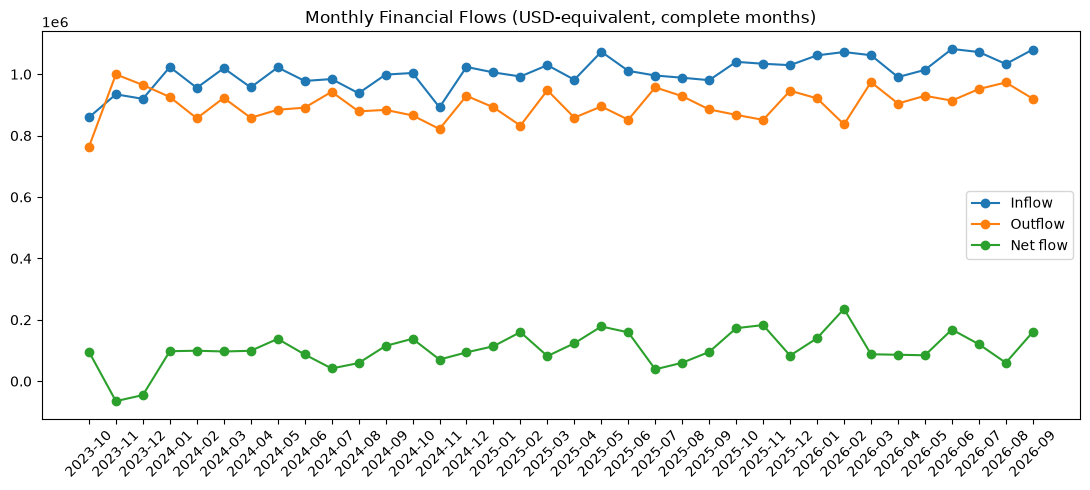

In [4]:
full = monthly[~monthly['is_partial_month']]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(full['month'], full['inflow'], marker='o', label='Inflow')
ax.plot(full['month'], full['outflow'], marker='o', label='Outflow')
ax.plot(full['month'], full['net_flow'], marker='o', label='Net flow')
ax.set_title('Monthly Financial Flows (USD-equivalent, complete months)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'monthly_financial_flows.png', dpi=150)
plt.show()
plt.close(fig)

## Important assumptions
- راجع تصنيفات `inflow_types` و`outflow_types` مع schema الحقيقي.
- لا تخلط completed مع failed أو reversed في الـKPIs.
- النمو الشهري غير معرّف عندما تكون قيمة الشهر السابق صفراً.
- العملة والفترة الزمنية يجب توثيقهما في Data Dictionary.